# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [44]:
# Import the library
import cv2
import numpy as np
from PIL import Image, ImageOps, ImageMath
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

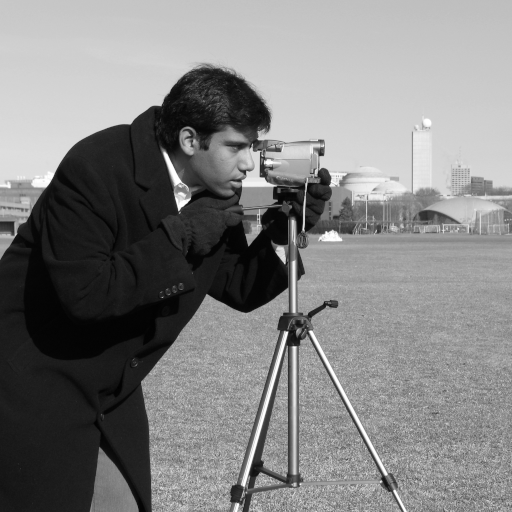

In [9]:
# ── Load image ────────────────────────────────────
image = data.camera()
img = Image.fromarray(image)
img


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [14]:
# Get the size of the image
img.size
# scaling factors
scale_factor = 2.0
height, width = image.shape[:2]

In [15]:
# ── 1. Increase size (scale ×2) ────────────────────
scaled_img =  (int(width * scale_factor), int(height * scale_factor))
# Resize the image using PIL's built-in method
Resized_img = cv2.resize(image, scaled_img, interpolation=cv2.INTER_AREA)

In [19]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
cv2.imwrite("task1_1_scaled.jpg", Resized_img)
print("Original image size:", image.shape[1], "x", image.shape[0])
print("Resized image size:", Resized_img.shape[1], "x", Resized_img.shape[0])

Original image size: 512 x 512
Resized image size: 1024 x 1024


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [70]:
img = cv2.imread('task1_1_scaled.jpg')

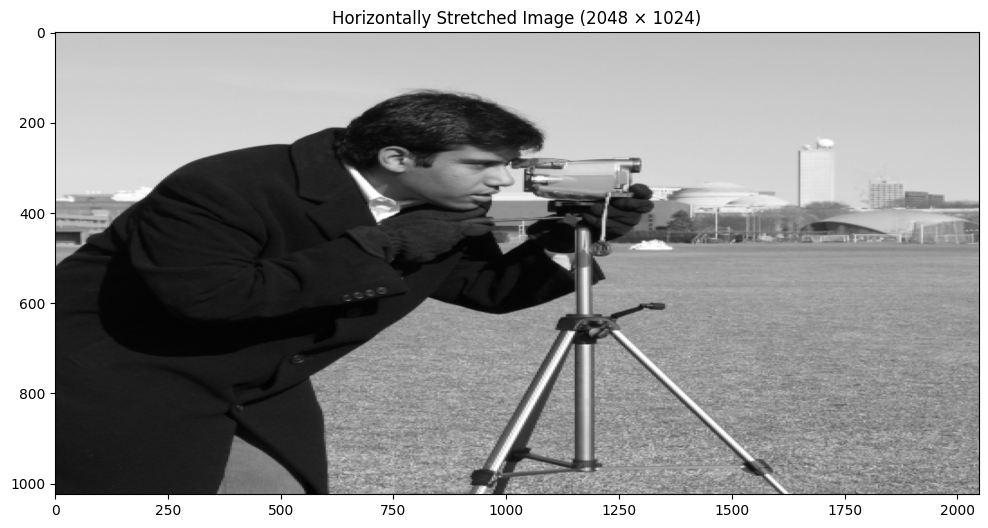

In [72]:
img_np = np.array(img)
height, width = img_np.shape[:2]
cx, cy = 2.0, 1.0
new_width = int(width * cx)
new_height = int(height * cy)

img_scaled = cv2.resize(img_np, (new_width, new_height), interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=(12, 6))
if img_scaled.ndim == 2:
    plt.imshow(img_scaled, cmap='gray')
else:
    plt.imshow(cv2.cvtColor(img_scaled, cv2.COLOR_BGR2RGB))

plt.title(f"Horizontally Stretched Image ({new_width} × {new_height})")
plt.axis('on')  
plt.show()



### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [24]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
img = Image.open('task1_1_scaled.jpg')
rotated_img = img.rotate(120, expand=True)
rotated_img.save('task1_2_rotated.jpg')
rotated_img.show()


### 3. Shear

In [39]:
# -- c. Get the image dimensions ────────────────────
image = Image.open('task1_1_scaled.jpg')
width, height = image.size


In [40]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

cx = 0.5  # Horizontal shear
cy = 0.0  # Vertical shear

In [41]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_image = image.transform(
    (1, height),
    Image.AFFINE,
    (1, cx, 0, cy, 1, 0)
)

In [43]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save('task1_3_sheared.jpg')

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

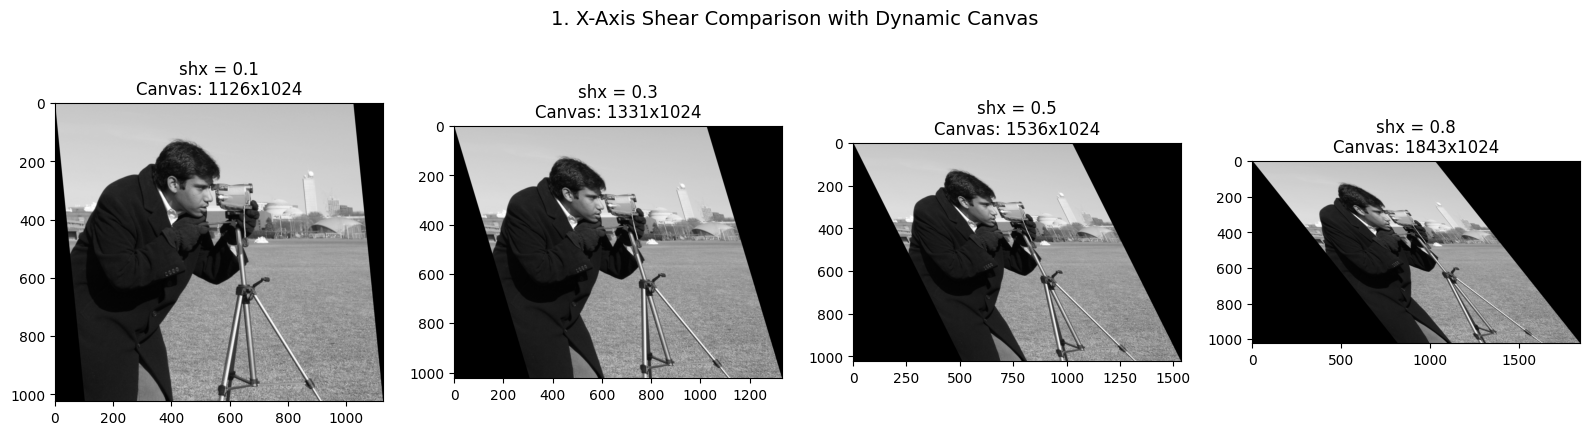

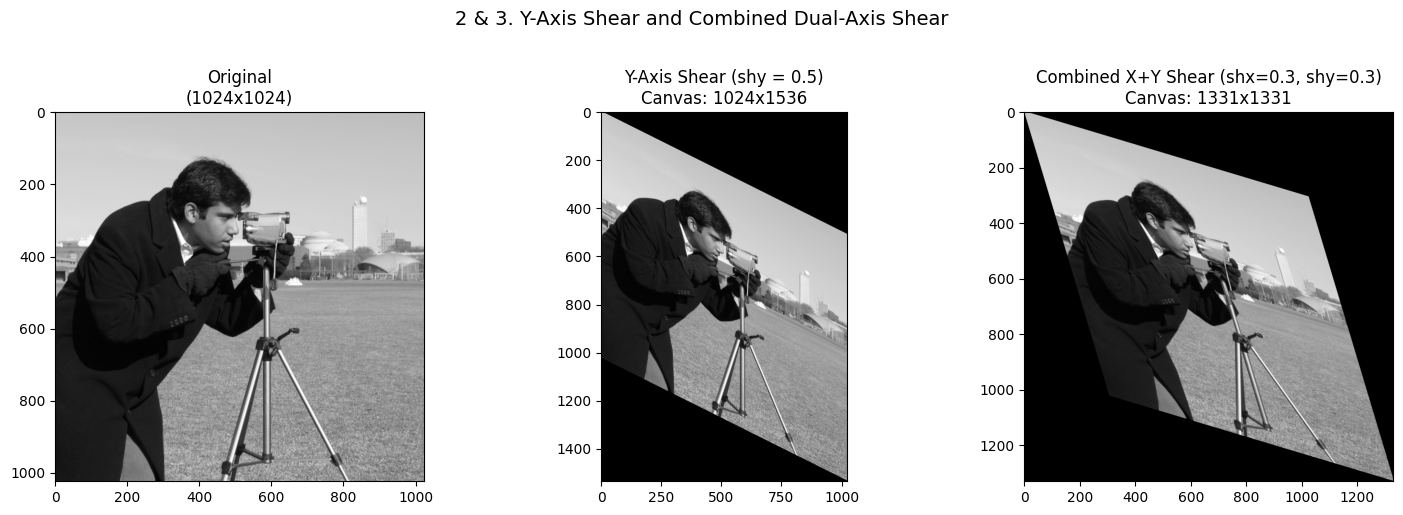

In [74]:
img_np = np.array(img)
h, w = img_np.shape[:2]

def apply_shear(image, shx=0.0, shy=0.0):
    """
    Applies horizontal (shx) and vertical (shy) shearing while dynamically
    adjusting the output canvas size to prevent clipping.
    """
    h_orig, w_orig = image.shape[:2]
    
    new_w = int(round(w_orig + abs(shx) * h_orig))
    new_h = int(round(h_orig + abs(shy) * w_orig))
    
    tx = abs(shx) * h_orig if shx < 0 else 0
    ty = abs(shy) * w_orig if shy < 0 else 0
    
    # 2x3 Affine Shear Matrix
    M = np.float32([
        [1,   shx, tx],
        [shy, 1,   ty]
    ])
    
    sheared = cv2.warpAffine(
        image, 
        M, 
        (new_w, new_h), 
        flags=cv2.INTER_LINEAR, 
        borderMode=cv2.BORDER_CONSTANT, 
        borderValue=(0, 0, 0)
    )
    return sheared, new_w, new_h
# Experiment 1: Varying X-Shear Factors (0.1, 0.3, 0.5, 0.8)
factors = [0.1, 0.3, 0.5, 0.8]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, shx in zip(axes, factors):
    sheared_img, nw, nh = apply_shear(img_np, shx=shx, shy=0.0)
    
    cmap = 'gray' if sheared_img.ndim == 2 else None
    ax.imshow(sheared_img, cmap=cmap)
    ax.set_title(f"shx = {shx}\nCanvas: {nw}x{nh}")
    ax.axis('on')

plt.suptitle("1. X-Axis Shear Comparison with Dynamic Canvas", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Experiments 2, 3 & 4: Y-Axis Shear vs Combined X+Y Shear
img_y_shear, wy, hy = apply_shear(img_np, shx=0.0, shy=0.5)
img_xy_shear, wxy, hxy = apply_shear(img_np, shx=0.3, shy=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(img_np, cmap='gray' if img_np.ndim == 2 else None)
axes[0].set_title(f"Original\n({w}x{h})")
axes[0].axis('on')

# Y-Axis Shear
axes[1].imshow(img_y_shear, cmap='gray' if img_y_shear.ndim == 2 else None)
axes[1].set_title(f"Y-Axis Shear (shy = 0.5)\nCanvas: {wy}x{hy}")
axes[1].axis('on')

# Combined X & Y Shear
axes[2].imshow(img_xy_shear, cmap='gray' if img_xy_shear.ndim == 2 else None)
axes[2].set_title(f"Combined X+Y Shear (shx=0.3, shy=0.3)\nCanvas: {wxy}x{hxy}")
axes[2].axis('on')

plt.suptitle("2 & 3. Y-Axis Shear and Combined Dual-Axis Shear", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [50]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
def apply_intensity_transformations(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")
    
    img_negative = 255 - img
    return img_negative


In [51]:
# Method 2: PIL's ImageOps
negative_img = ImageOps.invert(img)

In [ ]:
# ── 2. Log transformation ──────────────────────────

def apply_log_transform(img):
    img_float = img.astype(np.float32)
    
    max_val = np.max(img_float)
    if max_val == 0:
        return img.copy() 
    
    c_log = 255.0 / np.log(1.0 + max_val)
    
    img_log = c_log * np.log(1.0 + img_float)
    
    img_log = np.clip(img_log, 0, 255)
    return img_log.astype(np.uint8)


In [58]:

# ── 3. Power-law / Gamma correction ───────────────
img_np = np.array(img.convert("L")) if 'img' in locals() and hasattr(img, 'convert') else np.array(Image.open("your_image.jpg").convert("L"))

img_negative = 255 - img_np

img_float = img_np.astype(np.float32)
max_val = np.max(img_float)
c_log = 255.0 / np.log(1.0 + max_val) if max_val > 0 else 1.0
img_log = np.clip(c_log * np.log(1.0 + img_float), 0, 255).astype(np.uint8)

gamma = 0.5
img_normalized = img_float / 255.0
img_gamma = np.clip(np.power(img_normalized, gamma) * 255.0, 0, 255).astype(np.uint8)

top_row = np.hstack((img_np, img_negative))
bottom_row = np.hstack((img_log, img_gamma))
combined_result = np.vstack((top_row, bottom_row))


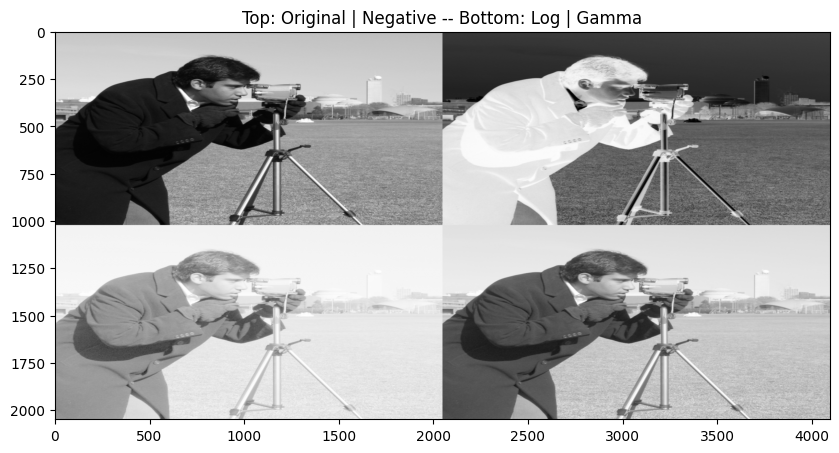

In [59]:
plt.figure(figsize=(10, 10))
plt.imshow(combined_result, cmap='gray')
plt.title('Top: Original | Negative -- Bottom: Log | Gamma')
plt.show()